In [98]:
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq

from data.loader import load_underlying_data, load_option_data
from option_builder.option_processing import OptionDatabase
from backtest_engine.engine import BacktestEngine
from portfolio.portfolio import Portfolio

# empty template
from strategy.template_option_strategy import TemplateOptionStrategy
from strategy.template_underlying_strategy import TemplateUnderlyingStrategy

# hedging strategy
from strategy.underlying_delta_hedging_strategy import UnderlyingDeltaHedgingStrategy

from strategy.synthetic_futures_basis_arbitrage_strategy import SyntheticFuturesBasisArbitrageStrategy
from strategy.synthetic_futures_basis_arbitrage_second_strategy import SyntheticFuturesBasisArbitrageSecondStrategy

from strategy.synthetic_futures_basis_arbitrage_strategy_ver2 import SyntheticFuturesBasisArbitrageStrategyVer2
from strategy.synthetic_futures_basis_arbitrage_second_strategy_ver2 import SyntheticFuturesBasisArbitrageSecondStrategyVer2

from strategy.synthetic_futures_basis_arbitrage_strategy_ver3 import SyntheticFuturesBasisArbitrageStrategyVer3

In [6]:
FILE_PATH_UNDERLYING = "~/Desktop/300ETF Data/沪深300ETF华泰柏瑞.xlsx"
FILE_PATH_OPTION = "~/Desktop/300ETF Data/OptionData/option_from_2019-2026.xlsx"

print("loading data...")

df_underlying = load_underlying_data(FILE_PATH_UNDERLYING)
df_option = load_option_data(FILE_PATH_OPTION)

print("underlying:", df_underlying.shape)
print("option:", df_option.shape)

loading data...
underlying: (1735, 2)
option: (187822, 29)


In [38]:
option_db = OptionDatabase(
    underlying_df=df_underlying,
    option_df=df_option,
    market="CN"
)

In [99]:
import importlib
import option_builder.option_processing as opt_mod
import backtest_engine.engine as eng_mod
import portfolio.portfolio as port_mod

# empty template
import strategy.template_option_strategy as opts_mod
import strategy.template_underlying_strategy as und_mod

# hedging strategy
import strategy.underlying_delta_hedging_strategy as und_del_mod

import strategy.synthetic_futures_basis_arbitrage_strategy as synfu_mod
import strategy.synthetic_futures_basis_arbitrage_second_strategy as synfu_sec_mod

import strategy.synthetic_futures_basis_arbitrage_strategy_ver2 as synfu_ver2_mod
import strategy.synthetic_futures_basis_arbitrage_second_strategy_ver2 as synfu_ver2_sec_mod

import strategy.synthetic_futures_basis_arbitrage_strategy_ver3 as synfu_ver3_mod


importlib.reload(und_mod)
importlib.reload(eng_mod)
importlib.reload(port_mod)

importlib.reload(opt_mod)
importlib.reload(opts_mod)

importlib.reload(und_del_mod)

importlib.reload(synfu_mod)
importlib.reload(synfu_sec_mod)

importlib.reload(synfu_ver2_mod)
importlib.reload(synfu_ver2_sec_mod)

importlib.reload(synfu_ver3_mod)

OptionDatabase = opt_mod.OptionDatabase
BacktestEngine = eng_mod.BacktestEngine
Portfolio = port_mod.Portfolio

TemplateUnderlyingStrategy = und_mod.TemplateUnderlyingStrategy
TemplateOptionStrategy = opts_mod.TemplateOptionStrategy

SyntheticFuturesBasisArbitrageStrategy = synfu_mod.SyntheticFuturesBasisArbitrageStrategy
SyntheticFuturesBasisArbitrageSecondStrategy = synfu_sec_mod.SyntheticFuturesBasisArbitrageSecondStrategy

UnderlyingDeltaHedgingStrategy = und_del_mod.UnderlyingDeltaHedgingStrategy

SyntheticFuturesBasisArbitrageStrategyVer2 = synfu_ver2_mod.SyntheticFuturesBasisArbitrageStrategyVer2
SyntheticFuturesBasisArbitrageSecondStrategyVer2 = synfu_ver2_sec_mod.SyntheticFuturesBasisArbitrageSecondStrategyVer2

SyntheticFuturesBasisArbitrageStrategyVer3 = synfu_ver3_mod.SyntheticFuturesBasisArbitrageStrategyVer3

In [ ]:
portfolio = Portfolio(cash=100_0000, multiplier=10000, 
                      option_cost=0.8, etf_cost_rate=0.0001, 
                      etf_min_cost=0, option_slippage=0.001, 
                      etf_slippage=0)

# option_strategy = TemplateOptionStrategy()
# option_strategy = SyntheticFuturesBasisArbitrageStrategy(upper_threshold = 0.002, down_threshold = 0.001, quantity = 100)
# option_strategy = SyntheticFuturesBasisArbitrageSecondStrategy(upper_threshold = 0.002, down_threshold = 0.001, quantity = 100)

# option_strategy = SyntheticFuturesBasisArbitrageStrategyVer2(upper_threshold = 0.002, down_threshold = 0.001, 
#                                                              quantity = 100, max_holding=3)
# option_strategy = SyntheticFuturesBasisArbitrageSecondStrategyVer2(upper_threshold = 0.002, down_threshold = 0.001, 
#                                                              quantity = 100, max_holding=20)

option_strategy = SyntheticFuturesBasisArbitrageStrategyVer3(upper_threshold = 0.002, down_threshold = 0.001, quantity = 100,
                                                             atm_roll_threshold=0.15)
underlying_strategy = TemplateUnderlyingStrategy()
# underlying_strategy = UnderlyingDeltaHedgingStrategy(hedge_threshold=0.05, hedge_ratio=1.0)

engine = BacktestEngine(
    option_db=option_db,
    option_strategy=option_strategy,
    underlying_strategy=underlying_strategy,
    portfolio=portfolio
)

engine.prepare_timeline(
    start="2020-01-01",
    end="2026-05-20"
)

results = engine.run()

2020-01-02 00:00:00
今天开仓： 2020-01-02 00:00:00
ATM strike: 4.1
call delta: 0.6237092729205667
put delta: -0.35697152060670057
2020-01-03 00:00:00
call delta: 0.6024373956393132
put delta: -0.3765683924212484
2020-01-06 00:00:00
call delta: 0.5651230104884921
put delta: -0.42435249776186723
2020-01-07 00:00:00
call delta: 0.6467091206078744
put delta: -0.33739558362096433
2020-01-08 00:00:00
call delta: 0.5453610253938929
put delta: -0.4512925381989723
2020-01-09 00:00:00
call delta: 0.6748261479732072
put delta: -0.30508112754354233
2020-01-10 00:00:00
call delta: 0.6793702919167436
put delta: -0.28612324887807805
2020-01-13 00:00:00
call delta: 0.8049328060017893
put delta: -0.139320787436352
2020-01-14 00:00:00
call delta: 0.76392703848988
put delta: -0.16945676760613804
2020-01-15 00:00:00
call delta: 0.7077107448977271
put delta: -0.23136250675315106
2020-01-16 00:00:00
call delta: 0.7321980328381664
put delta: -0.19963476244369338
2020-01-17 00:00:00
basis回落，全部平仓： 2020-01-17 00:00:

# Analysis

In [96]:
# 对交易
pd.set_option("display.max_rows", None)
pd.reset_option("display.max_rows")

trade_log = pd.DataFrame(portfolio.trade_history)
closed_df = pd.DataFrame(portfolio.closed_trade_history)

strategy_df = closed_df.copy()

# 确保时间格式正确
strategy_df["entry_time"] = pd.to_datetime(strategy_df["entry_time"])

# 按“同一天进场”聚合PnL
daily_pnl = (strategy_df.groupby(["entry_time", "exit_time"], as_index=False)["pnl"].sum())
daily_pnl["holding_days"] = (daily_pnl["exit_time"] - daily_pnl["entry_time"]).dt.days

In [102]:
closed_df

,instrument,id,entry_time,exit_time,entry_price,exit_price,quantity,direction,pnl
0,option,underlying,2020-01-02,2020-01-17,4.149000,4.151000,1000000,long,1.999917e+07
1,option,10002122.SH,2020-01-02,2020-01-17,0.093506,0.058058,100,short,3.528840e+04
2,option,10002131.SH,2020-01-02,2020-01-17,0.034835,0.004695,100,long,-3.029950e+04
3,option,underlying,2020-07-06,2020-07-13,4.784000,4.885000,1000000,long,1.009999e+09
4,option,10002645.SH,2020-07-06,2020-07-13,0.139660,0.135635,100,short,3.864700e+03
...,...,...,...,...,...,...,...,...,...
128,option,10010650.SH,2026-01-29,2026-02-02,0.083017,0.033634,100,short,4.922330e+04
129,option,10010659.SH,2026-01-29,2026-02-02,0.077577,0.202697,100,long,1.249596e+05
130,option,underlying,2026-01-29,2026-02-10,4.768000,4.733000,1000000,long,-3.500010e+08
131,option,10010888.SH,2026-02-02,2026-02-10,0.097902,0.145245,100,short,-4.750310e+04


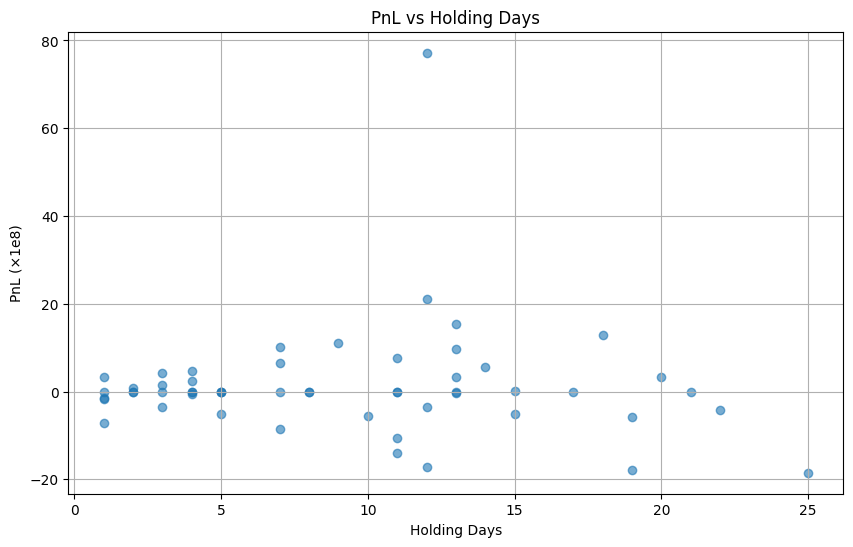

In [101]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.scatter(
    daily_pnl["holding_days"],
    daily_pnl["pnl"] / 1e8,
    alpha=0.6
)

plt.xlabel("Holding Days")
plt.ylabel("PnL (×1e8)")
plt.title("PnL vs Holding Days")
plt.grid(True)

plt.show()

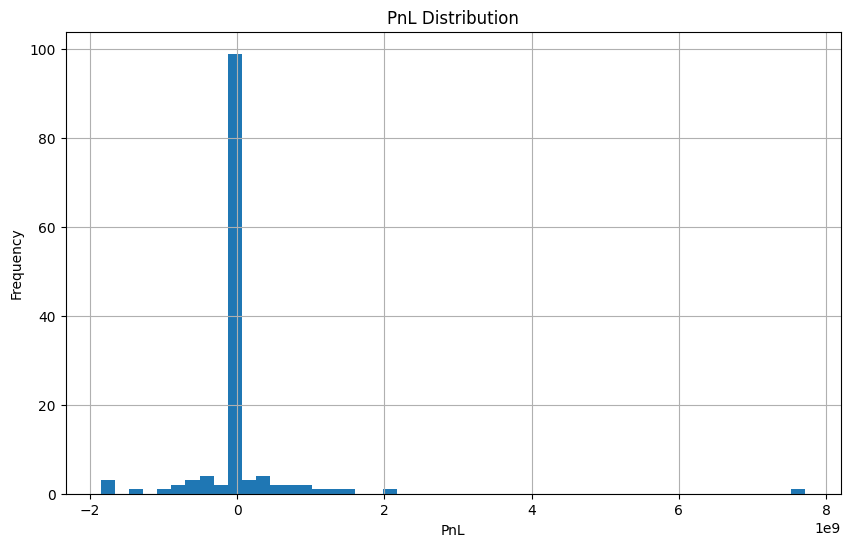

In [86]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.hist(closed_df["pnl"], bins=50)


plt.title("PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

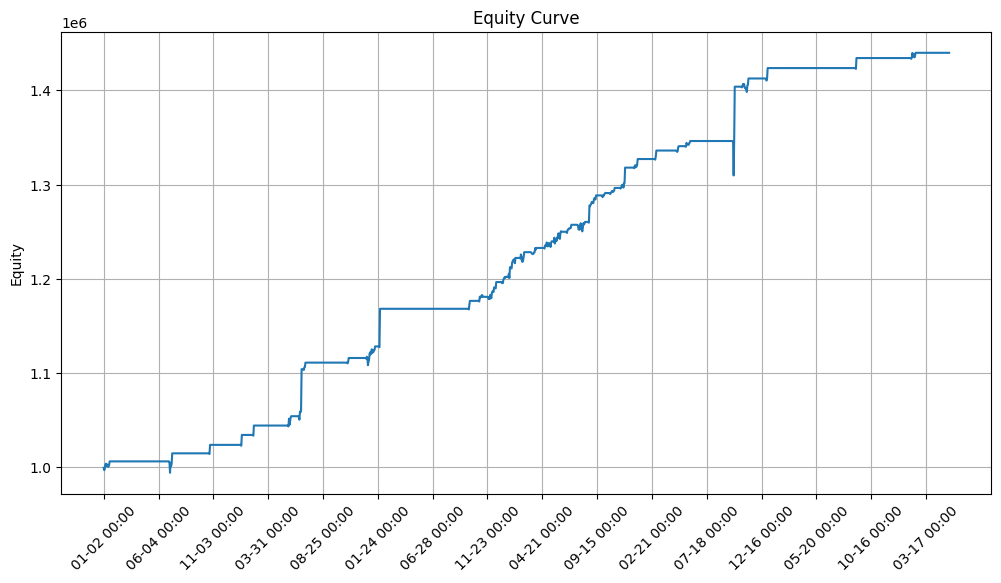

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(len(results_df)), results_df["equity"])

# 每隔一些点显示一个timestamp
step = 100

ax.set_xticks(range(0, len(results_df), step))
ax.set_xticklabels(
    results_df["timestamp"].iloc[::step].dt.strftime("%m-%d %H:%M"),
    rotation=45
)

ax.set_title("Equity Curve")
ax.set_ylabel("Equity")

plt.grid(True)
plt.show()

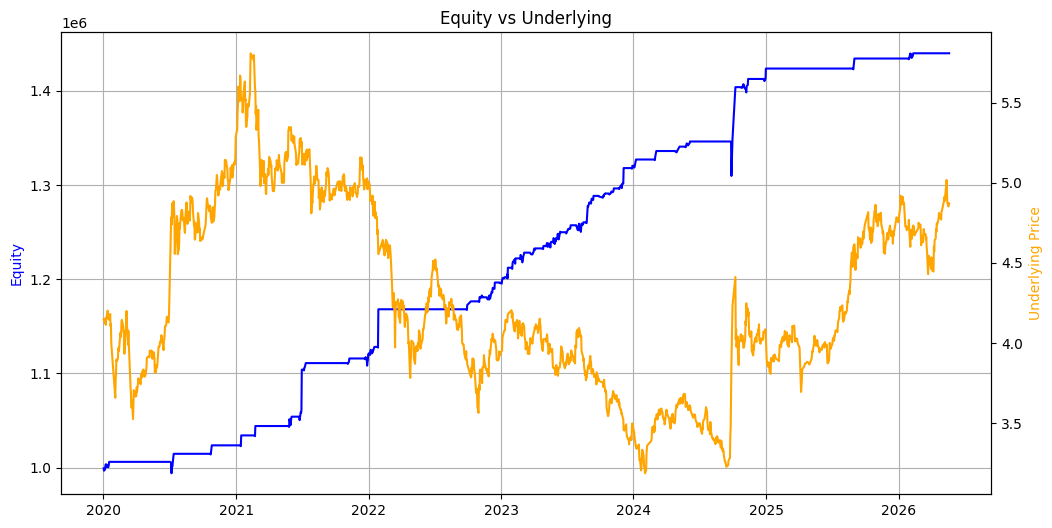

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

# ========= 1. 数据准备 =========
results_df = pd.DataFrame(results)
results_df["timestamp"] = pd.to_datetime(results_df["timestamp"])

df_underlying = df_underlying.copy()
df_underlying["日期"] = pd.to_datetime(df_underlying["日期"])

# ========= 2. 用 equity 时间做裁剪 =========
start_time = results_df["timestamp"].iloc[0]
end_time = results_df["timestamp"].iloc[-1]

df_u = df_underlying[
    (df_underlying["日期"] >= start_time) &
    (df_underlying["日期"] <= end_time)
]

# ========= 3. 画图 =========
fig, ax1 = plt.subplots(figsize=(12, 6))

# equity
ax1.plot(results_df["timestamp"], results_df["equity"], label="Equity", color="blue")
ax1.set_ylabel("Equity", color="blue")

# underlying（第二轴）
ax2 = ax1.twinx()
ax2.plot(df_u["日期"], df_u["收盘价(元)"], label="Underlying", color="orange")
ax2.set_ylabel("Underlying Price", color="orange")

# ========= 4. 格式 =========
ax1.set_title("Equity vs Underlying")
ax1.grid(True)

plt.show()

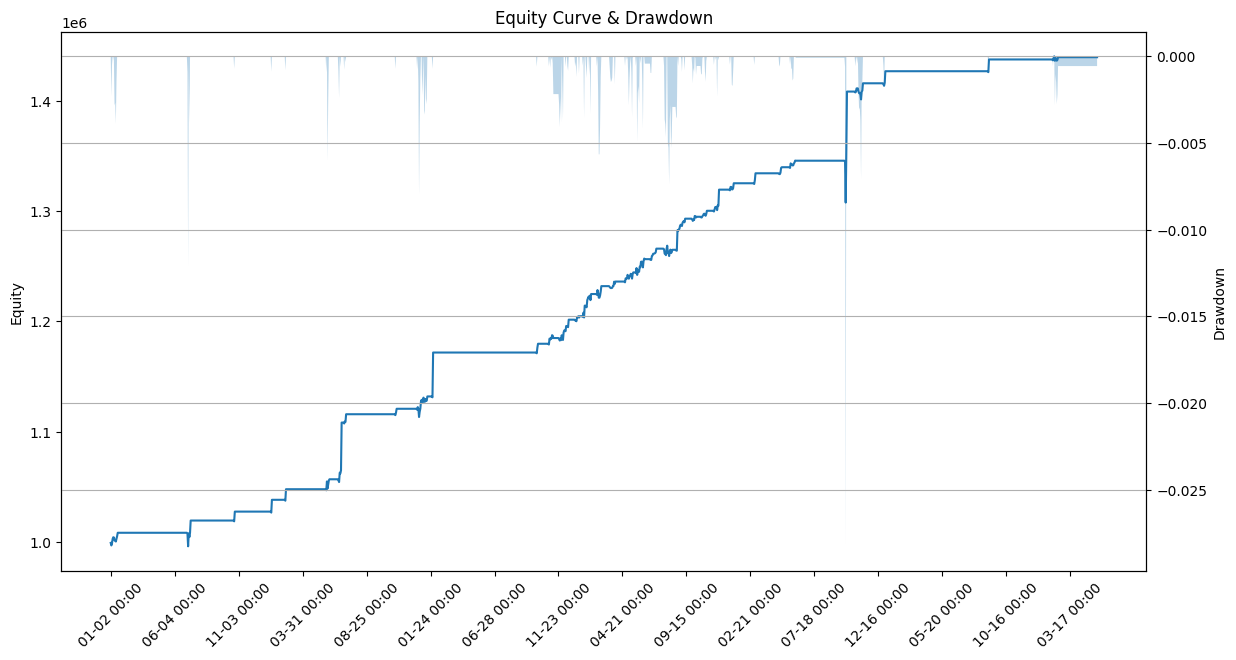

Annual Return: 5.88%
Annual Volatility: 3.85%
Max Drawdown: -2.83%
Sharpe Ratio: 1.53
Calmar Ratio: 2.08


In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("timestamp").reset_index(drop=True)

# =========================
# Return Series
# =========================

results_df["return"] = results_df["equity"].pct_change()

# =========================
# Drawdown
# =========================

results_df["cummax"] = results_df["equity"].cummax()

results_df["drawdown"] = (
    results_df["equity"] / results_df["cummax"] - 1
)

max_drawdown = results_df["drawdown"].min()

# =========================
# Annualized Return
# =========================

initial_equity = results_df["equity"].iloc[0]
final_equity = results_df["equity"].iloc[-1]

# total days
days = (
    results_df["timestamp"].iloc[-1]
    - results_df["timestamp"].iloc[0]
).days

annual_return = (
    final_equity / initial_equity
) ** (365 / days) - 1

# =========================
# Annualized Volatility
# =========================

# 日频:
annual_vol = (
    results_df["return"].std()
    * np.sqrt(252)
)

# =========================
# Sharpe Ratio
# =========================

risk_free_rate = 0

sharpe = (
    annual_return - risk_free_rate
) / annual_vol

# =========================
# Calmar Ratio
# =========================

calmar = annual_return / abs(max_drawdown)

# =========================
# Plot
# =========================

fig, ax1 = plt.subplots(figsize=(14, 7))

# Equity curve
ax1.plot(
    results_df.index,
    results_df["equity"],
    label="Equity"
)

ax1.set_ylabel("Equity")

# X axis labels
step = 100

ax1.set_xticks(range(0, len(results_df), step))

ax1.set_xticklabels(
    results_df["timestamp"]
    .iloc[::step]
    .dt.strftime("%m-%d %H:%M"),
    rotation=45
)

# =========================
# Drawdown axis
# =========================

ax2 = ax1.twinx()

ax2.fill_between(
    results_df.index,
    results_df["drawdown"],
    0,
    alpha=0.3,
    label="Drawdown"
)

ax2.set_ylabel("Drawdown")

# =========================
# Title
# =========================

ax1.set_title("Equity Curve & Drawdown")

plt.grid(True)

plt.show()

# =========================
# Metrics
# =========================

print(f"Annual Return: {annual_return:.2%}")

print(f"Annual Volatility: {annual_vol:.2%}")

print(f"Max Drawdown: {max_drawdown:.2%}")

print(f"Sharpe Ratio: {sharpe:.2f}")

print(f"Calmar Ratio: {calmar:.2f}")